# SetUp

In [2]:
!pip install -q langgraph langchain openai langsmith graphviz
!pip install -q langchain_community --upgrade

import os
from langchain.chat_models import ChatOpenAI
from langgraph.graph import StateGraph, END
from langsmith import traceable
from typing import Dict, Any
import graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.7 MB/s eta 0:00:00


In [3]:
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "multi-step-workflow-langgraph"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = ""  # Replace this securely
os.environ["OPENAI_API_KEY"] = "sk---"

# Multi-Step Nodes

In [4]:
# ---
# Step 1: Planning Node
@traceable(name="Planner")
def planner(state):
    question = state["input"]
    llm = ChatOpenAI(temperature=0)
    plan_prompt = f"Break down this task into steps: {question}"
    plan = llm.invoke(plan_prompt).content
    return {"plan": plan, "input": question}

In [5]:
# ---
# Step 2: Execution Node
@traceable(name="Executor")
def executor(state):
    plan = state["plan"]
    llm = ChatOpenAI(temperature=0)
    execution_prompt = f"Follow these steps to solve the task:\n{plan}"
    solution = llm.invoke(execution_prompt).content
    return {"solution": solution}

In [6]:
# ---
# Step 3: Summary Node
@traceable(name="Summarizer")
def summarizer(state):
    solution = state["solution"]
    llm = ChatOpenAI(temperature=0)
    summary_prompt = f"Summarize the following answer:\n{solution}"
    summary = llm.invoke(summary_prompt).content
    return {"final_answer": summary}

# Build LangGraph

In [7]:
# ---
# Build LangGraph
workflow = StateGraph(state_schema=Dict[str, Any])
workflow.add_node("planner", planner)
workflow.add_node("executor", executor)
workflow.add_node("summarizer", summarizer)

workflow.set_entry_point("planner")
workflow.add_edge("planner", "executor")
workflow.add_edge("executor", "summarizer")
workflow.set_finish_point("summarizer")

graph = workflow.compile()

# Visualize the Workflow Graph

In [10]:
# ---
# Visualize the Workflow Graph
from graphviz import Digraph
viz = Digraph()
viz.attr(rankdir="LR")
viz.node("planner", shape="box")
viz.node("executor", shape="box")
viz.node("summarizer", shape="box")
viz.node("END", shape="oval")

viz.edge("planner", "executor")
viz.edge("executor", "summarizer")
viz.edge("summarizer", "END")

viz.render("multi_step_workflow_simple", format="png", cleanup=False, view=True)

'multi_step_workflow_simple.png'

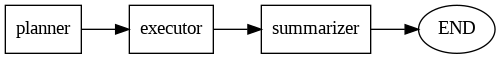

In [14]:
viz.render("react_langgraph_simple", format="png", cleanup=False, view=True)

from IPython.display import Image, display
display(Image(filename="multi_step_workflow_simple.png"))

# Output

In [12]:
# ---
# Run Example
inputs = {"input": "Create a short article about the future of AI in healthcare."}
output = graph.invoke(inputs)
print("\n Final Output:\n", output["final_answer"])


 Final Output:
 The answer suggests proofreading and editing the article for clarity, coherence, and accuracy, including relevant statistics, data, and quotes from experts. It also advises considering different stakeholders' perspectives, citing sources properly, sharing the article for feedback, and publishing it on a reputable platform to reach a wider audience and contribute to the conversation about AI in healthcare.


In [15]:
# ---
# Run Example
inputs = {"input": "Generate a step-by-step explanation of blockchain technology."}
output = graph.invoke(inputs)
print("\n Final Output:\n", output["final_answer"])


 Final Output:
 The answer suggests taking courses or certifications in blockchain technology, joining blockchain communities and forums, and experimenting with blockchain technology through projects or hackathons to deepen understanding and skills in the field.


In [13]:
# ---
# More Prompts to Try
print("""
Try questions like:
- Explain climate change in three steps.
- Write a plan and summary about using drones in agriculture.
- Generate a step-by-step explanation of blockchain technology.
""")


Try questions like:
- Explain climate change in three steps.
- Write a plan and summary about using drones in agriculture.
- Generate a step-by-step explanation of blockchain technology.

